In [16]:
import pandas as pd
import plotly.express as px


In [4]:
#load CSVs
# ── 1. CSVs laden ────────────────────────────────────────────
stock_data         = pd.read_csv("../data/stock_data.csv", index_col=0, parse_dates=True)
cumulative_returns = pd.read_csv("../data/cumulative_returns.csv", index_col=0, parse_dates=True)
rolling_volatility = pd.read_csv("../data/rolling_volatility.csv", index_col=0, parse_dates=True)
volatility         = pd.read_csv("../data/volatility.csv", index_col=0)
sharpe_ratio       = pd.read_csv("../data/sharpe_ratio.csv", index_col=0)
alpha_metrics      = pd.read_csv("../data/alpha_metrics.csv", index_col=0)
metadata           = pd.read_csv("../data/metadata.csv", index_col=0)

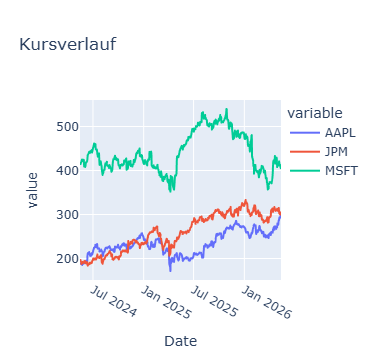

In [5]:
#plot price data
fig = px.line(stock_data, title="Kursverlauf")
fig.show()

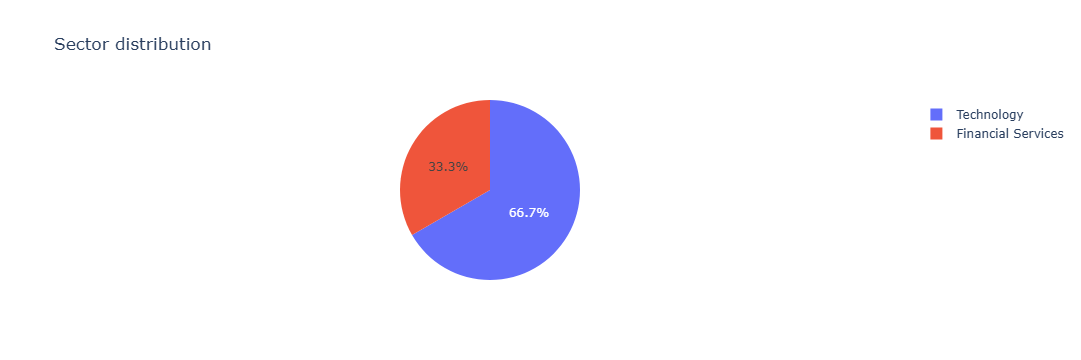

In [20]:
#plot sector distribution in pie chart
fig = px.pie(metadata, names="sector", title="Sector distribution")
fig.show()

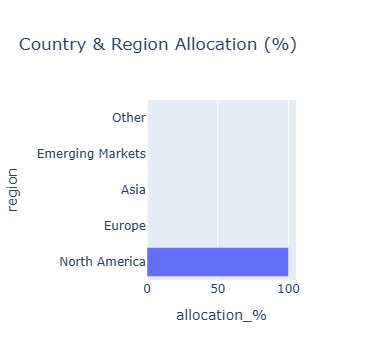

In [11]:
#plot geographical breakdown in bar chart
region_map = {
    "United States": "North America", "Canada": "North America", "Mexico": "North America",
    "Germany": "Europe", "France": "Europe", "United Kingdom": "Europe",
    "Switzerland": "Europe", "Netherlands": "Europe",
    "Japan": "Asia", "China": "Asia", "South Korea": "Asia",
    "India": "Emerging Markets", "Brazil": "Emerging Markets", "Taiwan": "Emerging Markets",
}

all_regions = ["North America", "Europe", "Asia", "Emerging Markets", "Other"]

metadata["region"] = metadata["country"].map(region_map).fillna("Other")

geo_data = (
    pd.DataFrame({"region": all_regions})
    .merge(metadata["region"].value_counts().rename("count").reset_index(), on="region", how="left")
    .fillna(0)
    .assign(**{"allocation_%": lambda x: (x["count"] / x["count"].sum() * 100).round(1)})
)

fig = px.bar(geo_data, x="allocation_%", y="region", orientation="h", title="Country & Region Allocation (%)")
fig.show()

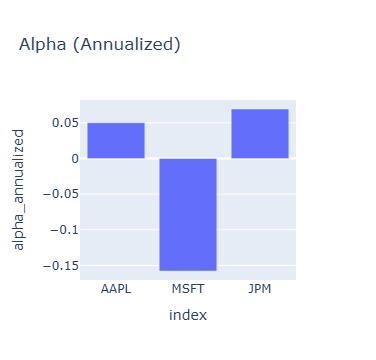

In [17]:
#plot alpha in bar chart
fig = px.bar(alpha_metrics, x=alpha_metrics.index, y="alpha_annualized", title="Alpha (Annualized)")
fig.show()

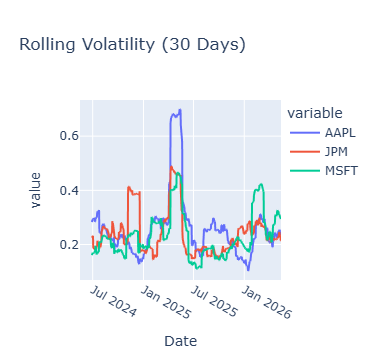

In [18]:
#plot rolling volatility in line chart
fig = px.line(rolling_volatility, title="Rolling Volatility (30 Days)")
fig.show()

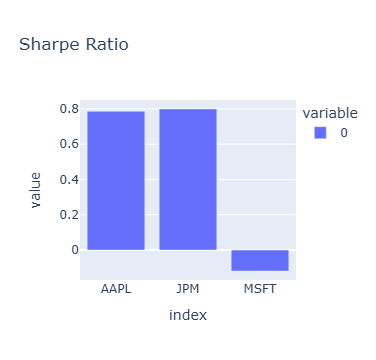

In [19]:
#plot sharpe ratio as bar chart
fig = px.bar(sharpe_ratio, title="Sharpe Ratio")
fig.show()